# Equilibrium

At high temperatures, the reverse rates become important and we can come into equilibrium---resulting in nuclear statistical equilibrium (NSE).

Let's see this by reintegrating our "aprox13" network.

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12", "o16", "ne20", "na23",
                           "mg24", "al27", "si28", "p31", "s32",
                           "cl35", "ar36", "k39", "ca40",
                           "sc43", "ti44", "v47", "cr48",
                           "mn51", "fe52", "co55", "ni56"])

In [3]:
from pynucastro.rates.aprox_family_rates import make_CO_approx_rates

In [4]:
approx_net = pyna.PythonNetwork(rates=net.get_rates())

In [5]:
approx_net.make_CO_burning_approx("C")
approx_net.remove_nuclei(["na23"])

In [6]:
approx_net.make_CO_burning_approx("CO")
approx_net.remove_nuclei(["al27"])

In [7]:
approx_net.make_CO_burning_approx("O")
approx_net.remove_nuclei(["p31"])

In [8]:
approx_net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51", "co55"])
approx_net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51", "co55"])

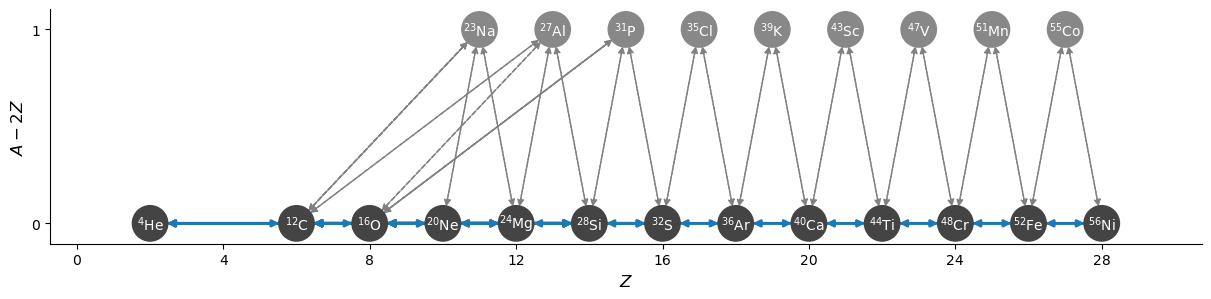

In [9]:
fig = approx_net.plot(rotated=True,
                      size=(1200, 300), node_size=600, node_font_size=10)

Now let's pick a very high temperature.

In [10]:
rho = 1.e7
T = 6.e9

In [11]:
comp = pyna.Composition(approx_net.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("he4")] = 1.0
Y0 = comp.get_molar_array()

In [12]:
tmax = 100.0

In [13]:
sol_approx = approx_net.integrate_network(tmax, rho, T, Y0, rtol=1.e-6)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:412: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


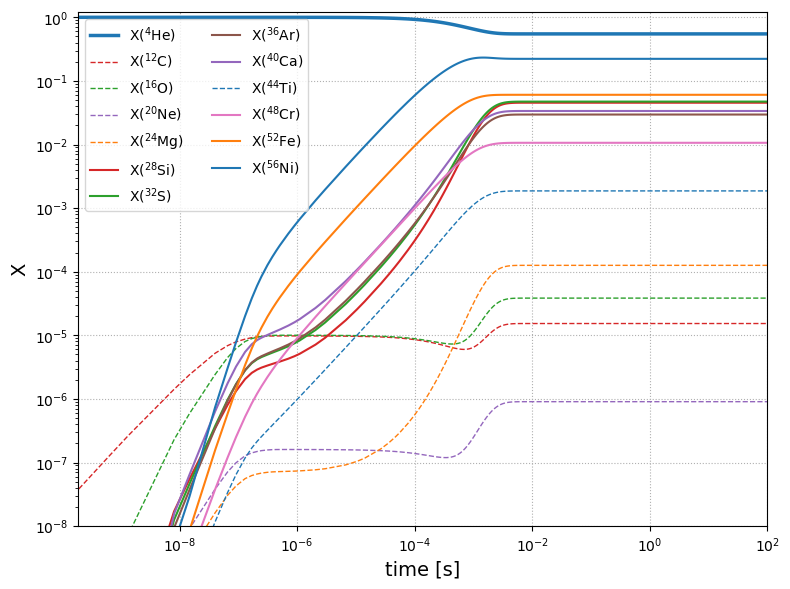

In [14]:
fig = sol_approx.plot_evolution(three_level_style=True, ymin=1.e-8)

Now we see that after about $10^{-2}~\mathrm{s}$, we enter equilibrium ($dX/dt = 0$).

## NSE

We can solve for nuclear statistic equilibrium directly.  Here's an overview (taken from [pynucastro's intro to NSE](https://pynucastro.github.io/pynucastro/nse-intro.html)

### NSE assumptions

To get the NSE constraint equations we assume:

* every isotope is connected to the free nucleons, neutrons and protons, through a series of strong nuclear reactions.
  
* we are in chemical equilibrium, so

  $$(A, Z) \rightleftharpoons Z \  \mathrm{p} + N \ \mathrm{n}$$

  giving:

  $$\mu_i = Z_i \mu_p + N_i \mu_n$$

* The nuclei obey Maxwell-Boltzmann statistics, so:

  $$\mu_i = \mu_i^{\mathrm{kin}} + m_i c^2 + \mu_i^c$$

  where $\mu_i^c$ is the Coulomb potential and
  
  $$\mu_i^{\mathrm{kin}} = Z_i (\mu_p^{\mathrm{kin}} + \mu_p^c) + N_i \mu_n^{\mathrm{kin}} + \underbrace{(Z_i m_p + N_i m_n - m_i) c^2}_{B_i} - \mu^c_i$$

  where $B_i$ is the binding energy of the isotope.

  Maxwell-Boltzmann statistics then give us:

  $$X_{i, \mathrm{NSE}} = \dfrac{(m_i)^{5/2}}{\rho} g_i \left( \dfrac{k_B T}{2\pi \hbar^2} \right)^{3
/2} \exp{\left( \dfrac{Z_i (\mu_p^{\mathrm{kin}} + \mu_p^c) + N_i \mu_n^{\mathrm{kin}} + B_i - \mu^c
_i}{k_B T} \right)}$$

### NSE constraint equations

NSE allows us to just solve for $\mu_p^{\mathrm{kin}}$ and $\mu_n^{\mathrm{kin}}$
via:

* Conservation of mass:

  $$\sum_i X_i^{\mathrm{NSE}}(\mu_p^{\mathrm{kin}}, \mu_n^{\mathrm{kin}}) - 1 = 0$$

* Conservation of charge:

  $$\sum_i \frac{Z_i}{A_i} X_i^{\mathrm{NSE}} (\mu_p^{\mathrm{kin}}, \mu_n^{\mathrm{kin}}) - Y_e = 0$$


We can create a network that knows about NSE

In [17]:
nse_net = pyna.NSENetwork(rates=approx_net.get_rates())

Now we can solve for the NSE state.  The only composition information we need to provide is the electron fraction.

In [24]:
comp_nse = nse_net.get_comp_nse(rho, T, comp.ye)

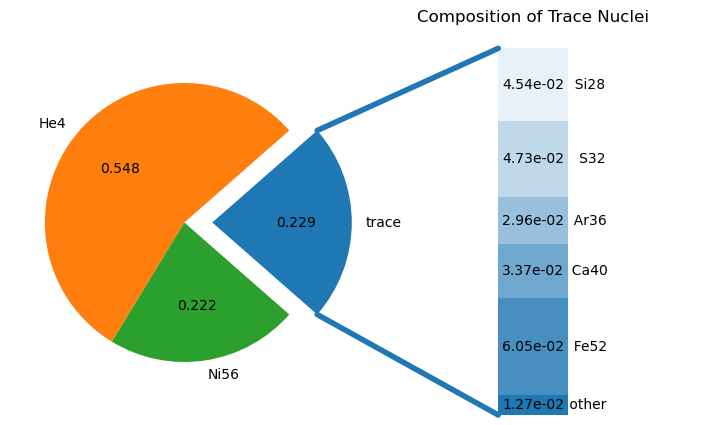

In [25]:
fig = comp_nse.plot()

If we are in equilibrium, then no integration is needed.